In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore')

In [3]:
df = pd.read_csv("cl_hier.csv")

In [4]:
df[:1]

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39


In [5]:
df.shape

(200, 5)

In [6]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [7]:
df = df.drop(["Gender", "CustomerID"], axis = 1)

In [8]:
# dbscan= 4, meanshift= 3, kmeans =4

In [9]:
from sklearn.cluster import DBSCAN

In [10]:
cluster  =DBSCAN(eps=3, min_samples=3).fit(df)

In [11]:
cluster.labels_

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1,  0, -1, -1, -1,  0, -1, -1, -1, -1,  0,
       -1, -1, -1, -1,  1, -1, -1,  1,  1, -1, -1,  2,  2,  2, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [12]:
from sklearn.cluster import KMeans

In [13]:
kmeans = KMeans(n_clusters=4)

In [58]:
kmeans.fit(df)

KMeans(n_clusters=4)

In [15]:
labels=kmeans.labels_

In [16]:
kmeans.cluster_centers_

array([[24.47916667, 39.89583333, 64.41666667],
       [50.60810811, 46.58108108, 40.25675676],
       [40.39473684, 87.        , 18.63157895],
       [32.875     , 86.1       , 81.525     ]])

In [17]:
# kmeans = 0, 1, 2, 3

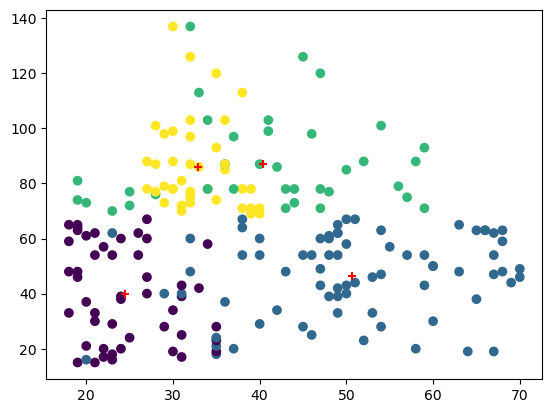

In [18]:
plt.scatter(df['Age'], df['Annual Income (k$)'], cmap= 'viridis', c=labels, marker='o')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], color='red', marker='+')
plt.show()

In [19]:
# plt.title("clusters")
# sns.scatterplot(data= scale_data, x="Annual Income (k$)", y= "Age")
# plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c= "red")
# plt.show()

In [20]:
from sklearn.cluster import MeanShift, estimate_bandwidth

In [21]:
bandwidth = estimate_bandwidth(df, quantile=0.2, n_samples=len(df))

In [22]:
print(bandwidth)

33.20227510761323


In [23]:
mean_shift = MeanShift(bandwidth=30)

In [24]:
ms=mean_shift.fit(df)

In [25]:
ms.labels_

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1])

In [26]:
labels = ms.labels_

In [27]:
# meanshift = 0,1,2

In [28]:
ms.cluster_centers_

array([[42.38202247, 55.74157303, 50.21348315],
       [31.49019608, 74.        , 71.98039216],
       [40.625     , 79.725     , 22.175     ]])

In [29]:
df[:1]

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39


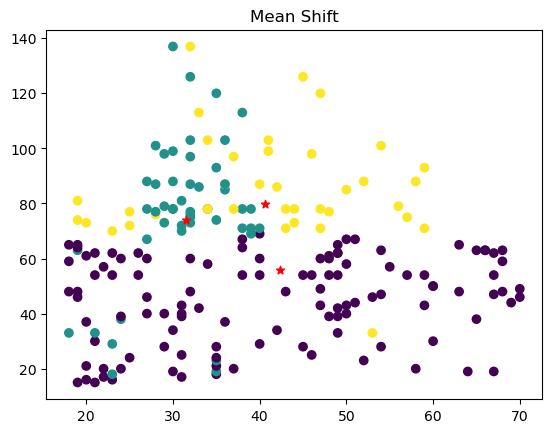

In [30]:
plt.scatter(df["Age"], df["Annual Income (k$)"],c = labels, cmap= "viridis", marker="o")
plt.scatter(ms.cluster_centers_[:,0], ms.cluster_centers_[:,1], color = "red", marker="*")
plt.title('Mean Shift')
plt.show()

In [31]:
df[:1]

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39


In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [33]:
vectorizer = TfidfVectorizer(max_features=100)

In [34]:
vectorizer

TfidfVectorizer(max_features=100)

In [35]:
x = vectorizer.fit_transform(df)

In [56]:
x = x.toarray()

In [57]:
x

array([[0.        , 1.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.70710678, 0.70710678, 0.        ,
        0.        ],
       [0.57735027, 0.        , 0.        , 0.        , 0.57735027,
        0.57735027]])

In [36]:
# mean_shift, kmeans, cluster, scale_data

In [37]:
corpus = [
    ("what is the dataset about",
     "The dataset is a clustering dataset used to group similar data points based on their features."),

    ("which models we used",
     "We used KMeans, MeanShift, and DBSCAN algorithms for clustering."),

    ("what is clustering",
     "Clustering is an unsupervised learning technique that groups data points based on similarity without using labels."),

    ("what is kmeans",
     "KMeans is a centroid-based clustering algorithm that divides data into k clusters based on distance from cluster centers."),

    ("what is meanshift",
     "MeanShift is a clustering algorithm that identifies clusters by finding dense regions in the feature space."),

    ("what is dbscan",
     "DBSCAN (Density-Based Spatial Clustering of Applications with Noise) groups together points that are closely packed and marks outliers as noise."),

    ("how to choose the number of clusters",
     "For KMeans, the number of clusters can be found using the Elbow Method or Silhouette Score."),

    ("what are the evaluation metrics",
     "We can evaluate clustering using metrics like Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Score."),

    ("what is the difference between kmeans and dbscan",
     "KMeans requires specifying the number of clusters beforehand, while DBSCAN automatically detects clusters and can identify noise points."),

    ("thank you",
     "You're welcome! Happy clustering! 😊"),

    ("bye",
     "Goodbye! Keep exploring data! 👋")
]


In [38]:
import nltk

In [39]:
from nltk.tokenize import word_tokenize

In [40]:
from nltk.stem import PorterStemmer, WordNetLemmatizer

In [41]:
from nltk.corpus import stopwords

In [42]:
from nltk import ngrams, pos_tag, ne_chunker

In [43]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to C:\Users\Pawanpreet
[nltk_data]     Kaur\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [44]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Pawanpreet
[nltk_data]     Kaur\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [45]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to C:\Users\Pawanpreet
[nltk_data]     Kaur\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [46]:
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Pawanpreet Kaur\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [47]:
nltk.download('maxent_ne_chunker')

[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     C:\Users\Pawanpreet Kaur\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!


True

In [48]:
nltk.download('words')

[nltk_data] Downloading package words to C:\Users\Pawanpreet
[nltk_data]     Kaur\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!


True

In [49]:
import joblib

In [50]:
joblib.dump(mean_shift, "ms_model.pkl")

['ms_model.pkl']

In [51]:
joblib.dump(kmeans, "kmean_model.pkl")

['kmean_model.pkl']

In [52]:
joblib.dump(cluster, "dbscan_model.pkl")

['dbscan_model.pkl']

In [53]:
joblib.dump(corpus, "corpus.pkl")

['corpus.pkl']

In [54]:
df

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40
...,...,...,...
195,35,120,79
196,45,126,28
197,32,126,74
198,32,137,18
